In [1]:
pip install torch pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\PRATYUSH\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


cuda
Epoch 1, Loss: 0.17021358013153076
Epoch 2, Loss: 0.1638571321964264
Epoch 3, Loss: 0.15792714059352875
Epoch 4, Loss: 0.1522526890039444
Epoch 5, Loss: 0.14697860181331635
Epoch 6, Loss: 0.14182479679584503
Epoch 7, Loss: 0.13702355325222015
Epoch 8, Loss: 0.13242410123348236
Epoch 9, Loss: 0.12785963714122772
Epoch 10, Loss: 0.12359882146120071
Epoch 11, Loss: 0.12040006369352341
Epoch 12, Loss: 0.11692577600479126
Epoch 13, Loss: 0.11294202506542206
Epoch 14, Loss: 0.10867353528738022
Epoch 15, Loss: 0.10331381112337112
Epoch 16, Loss: 0.09614382684230804
Epoch 17, Loss: 0.08638804405927658
Epoch 18, Loss: 0.0747307762503624
Epoch 19, Loss: 0.06250832229852676
Epoch 20, Loss: 0.05093172937631607
Epoch 21, Loss: 0.04089580848813057
Epoch 22, Loss: 0.03396483510732651
Epoch 23, Loss: 0.029920028522610664
Epoch 24, Loss: 0.028175044804811478
Epoch 25, Loss: 0.028487874194979668
Epoch 26, Loss: 0.028296547010540962
Epoch 27, Loss: 0.027840064838528633
Epoch 28, Loss: 0.026123123243

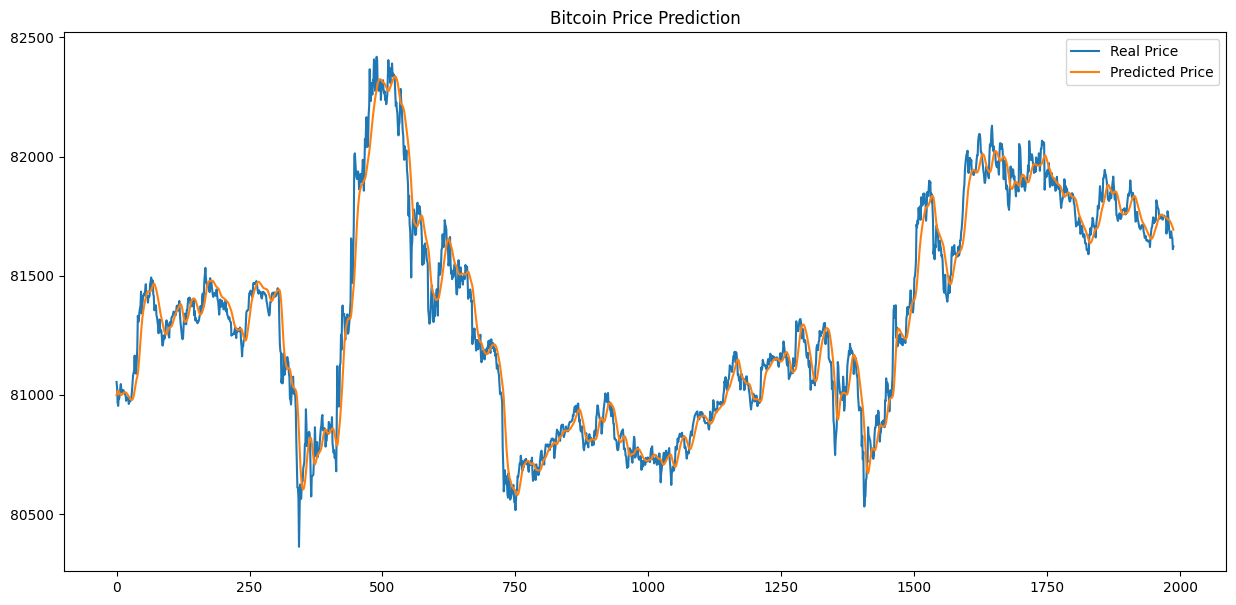

C:\Users\PRATYUSH\AppData\Local\Temp\ipykernel_7924\1112945292.py:122: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("bitcoin_lstm.pth"))


<All keys matched successfully>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

df = pd.read_csv(r"C:\Users\PRATYUSH\OneDrive\Desktop\college\cses\btcusd_1-min_data.csv")
df = df.tail(10000)
df.dropna(inplace=True)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
features = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume']
data = df[features].values

scaler_features = MinMaxScaler(feature_range=(-1, 1))
scaler_close = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler_features.fit_transform(data)
scaler_close.fit(data[:, 3:4])

sequence_length = 60
X = []
y = []
for i in range(sequence_length, len(data_scaled)):
    X.append(data_scaled[i-sequence_length:i])
    y.append(data_scaled[i,0])
X = np.array(X)
y = np.array(y)

split_index = int(len(X) * 0.8)
X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train, y_train)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=False)

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

class BitcoinLSTM(nn.Module):
    def __init__(self):
        super(BitcoinLSTM, self).__init__()
        self.lstm = nn.LSTM(
          input_size=5,
          hidden_size=128,
          num_layers=3,
          dropout=0.2,
          batch_first=True)
        self.fc1 = nn.Linear(128, 64)
        self.tanh = nn.Tanh()
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

model = BitcoinLSTM()
model = model.to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005
)
epochs=100

for epoch in range(epochs):
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train.unsqueeze(1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

model.eval()
with torch.no_grad():
  predictions = model(X_test.to(device)).cpu().numpy()
  real_prices = y_test.cpu().numpy()
  predictions_inv = scaler_close.inverse_transform(predictions.reshape(-1, 1)).flatten()
  real_prices_inv = scaler_close.inverse_transform(real_prices.reshape(-1, 1)).flatten()

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(real_prices_inv, predictions_inv))
print("RMSE:", rmse)

plt.figure(figsize=(15,7))
plt.plot(real_prices_inv[:10000], label="Real Price")
plt.plot(predictions_inv[:10000], label="Predicted Price")
plt.legend()
plt.title("Bitcoin Price Prediction")
plt.show()

torch.save(
    model.state_dict(),
    "bitcoin_lstm.pth")
model = BitcoinLSTM()
model.load_state_dict(
    torch.load("bitcoin_lstm.pth"))